# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 30 dias | Ventana salida: 30 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [43]:
VENTANA_ENTRADA = 30   # dias de entrada
VENTANA_SALIDA  = 30   # dias de salida (promedio)


In [44]:
#Ejecutar solo si se quiere entrenar en GPU
import subprocess, sys, os

# ── Instalar PyTorch con CUDA si no esta disponible ──────────────────
try:
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError('torch sin CUDA')
except (ImportError, RuntimeError):
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch', '--index-url', 'https://download.pytorch.org/whl/cu128'
    ])
    import torch

# ── Cambiar el backend de Keras a torch ANTES de importar keras ───────
# IMPORTANTE: esta celda debe ejecutarse ANTES de la celda de imports
if 'keras' in sys.modules:
    raise RuntimeError(
        'keras ya fue importado con otro backend. '
        'Reinicia el kernel, ejecuta ESTA celda primero y luego la de imports.'
    )
os.environ['KERAS_BACKEND'] = 'torch'

# ── Verificar GPU ─────────────────────────────────────────────────────
import torch
if not torch.cuda.is_available():
    raise RuntimeError('CUDA no disponible. Revisa la instalacion de PyTorch+CUDA.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  ({vram_gb:.1f} GB VRAM)')
print(f'CUDA: {torch.version.cuda}  |  PyTorch: {torch.__version__}')

# ── Verificar que un tensor de prueba va realmente a GPU ─────────────
_t = torch.tensor([1.0]).cuda()
assert _t.device.type == 'cuda', 'El tensor no esta en CUDA'
del _t
print('Tensor de prueba en CUDA: OK')

# ── Verificar backend de Keras tras importarlo ────────────────────────
import keras
backend_activo = keras.backend.backend()
if backend_activo != 'torch':
    raise RuntimeError(
        f'Backend de Keras es "{backend_activo}", se esperaba "torch". '
        'Reinicia el kernel y ejecuta esta celda antes que la de imports.'
    )
print(f'Backend Keras: {backend_activo}  ->  entrenamiento en GPU activado')


RuntimeError: keras ya fue importado con otro backend. Reinicia el kernel, ejecuta ESTA celda primero y luego la de imports.

In [45]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import (
    construir_dense, construir_dense_v2, construir_dense_v3,
    construir_dense_v4, construir_dense_v5, construir_dense_v6,
    construir_recurrente, construir_recurrente_v2, construir_recurrente_v3,
    construir_recurrente_v4, construir_recurrente_v5, construir_recurrente_v6,
    construir_conv1d, construir_conv1d_v2, construir_conv1d_v3,
    construir_conv1d_v4, construir_conv1d_v5, construir_conv1d_v6,
    construir_mixto,
)
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
CALLBACKS = [
    EarlyStopping(patience=10000, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=500, verbose=1),
]



---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [46]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16131, 30, 23)  |  y: (16131, 23)
Train: (13065, 30, 23)  Val: (1452, 30, 23)  Test: (1614, 30, 23)


## 1.2 Baselines

In [47]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.002148  0.001739  0.002435         0
BuyAndHold   0.002205  0.001702  0.002320         0


## 1.3 Modelos Dense (MLP)

In [48]:
def aplicar_hp(modelo, lr=None, l2=None):
    """Aplica lr y/o L2 a un modelo ya construido sin reiniciar Keras."""
    if lr is not None:
        modelo.optimizer.learning_rate.assign(lr)
    if l2 is not None:
        reg = regularizers.l2(l2)
        for layer in modelo.layers:
            if hasattr(layer, "kernel"):
                layer.kernel_regularizer = reg
        # recompila solo la funcion de perdida; el optimizer y sus pesos se conservan
        modelo.compile(optimizer=modelo.optimizer, loss=modelo.loss)


In [49]:
modelo_dense = construir_dense(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense, lr=1e-4, l2=1e-4)
modelo_dense.summary()
hist_dense = modelo_dense.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=250, batch_size=100000, verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step - loss: 0.0136 - val_loss: 0.0078
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0132 - val_loss: 0.0075
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0128 - val_loss: 0.0072
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0126 - val_loss: 0.0070
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0122 - val_loss: 0.0067
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0119 - val_loss: 0.0065
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0116 - val_loss: 0.0063
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0114 - val_loss: 0.0061
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0111 - val_loss: 0.0060
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0109 - val_loss: 0.0058
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0106 - val_loss: 0.0057
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0

{'modelo': 'Dense', 'mae_train': 0.002203198541232323, 'mae_val': 0.0017023171802784745, 'mae_test': 0.0023512470517471243, 'n_params': 212759}


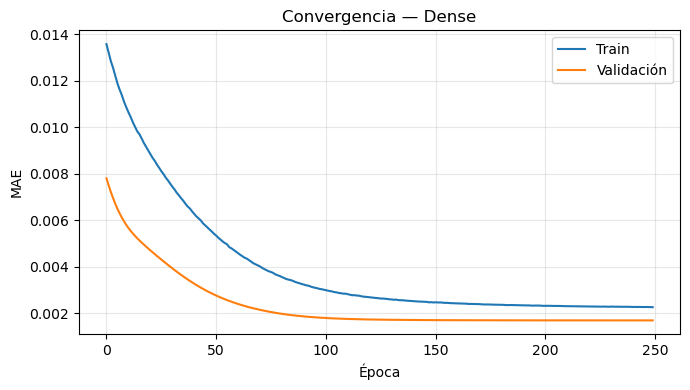

In [50]:
graficar_convergencia(hist_dense, 'Dense')
resultado_dense = evaluar_modelo(modelo_dense, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense)

### Dense v2 -- 3 capas estrechas (128->64->32), Dropout 0.3

In [51]:
modelo_dense_v2 = construir_dense_v2(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v2, lr=1e-4, l2=1e-14)
modelo_dense_v2.summary()
hist_dense_v2 = modelo_dense_v2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=200, batch_size=13765 , verbose=1)

Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │        88,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,543 (388.84 KB)

 Trainable params: 99,543 (388.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0165 - val_loss: 0.0080
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0161 - val_loss: 0.0076
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0156 - val_loss: 0.0072
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0152 - val_loss: 0.0069
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0147 - val_loss: 0.0065
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0143 - val_loss: 0.0062
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0137 - val_loss: 0.0059
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0134 - val_loss: 0.0056
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0130 - val_loss: 0.0053
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0126 - val_loss: 0.0050
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0122 - val_loss: 0.0048
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0119 - va

{'modelo': 'Dense_v2', 'mae_train': 0.0022102424013028957, 'mae_val': 0.0017000079258566296, 'mae_test': 0.0023566592380036906, 'n_params': 99543}


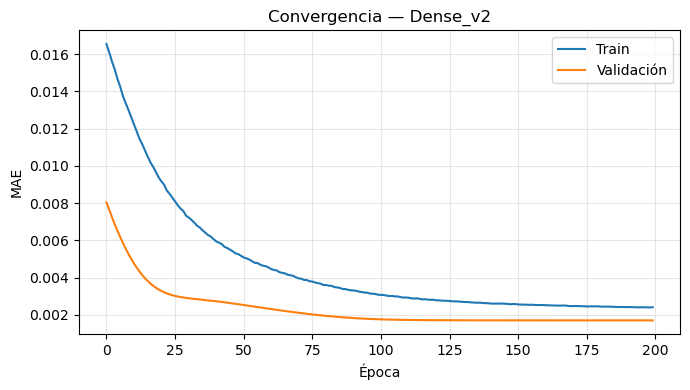

In [52]:
graficar_convergencia(hist_dense_v2, 'Dense_v2')
resultado_dense_v2 = evaluar_modelo(modelo_dense_v2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v2')
print(resultado_dense_v2)

### Dense v3 -- 4 capas anchas (512->256->128->64), LR=1e-4

In [53]:
modelo_dense_v3 = construir_dense_v3(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v3, lr=1e-4, l2=1e-2)
modelo_dense_v3.summary()
hist_dense_v3 = modelo_dense_v3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=200, batch_size=13765 ,   verbose=1)

Model: "Dense_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 512)            │       353,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,767 (2.01 MB)

 Trainable params: 527,767 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0085 - val_loss: 0.0050
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.0077 - val_loss: 0.0044
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.0070 - val_loss: 0.0039
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.0063 - val_loss: 0.0035
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.0058 - val_loss: 0.0032
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0053 - val_loss: 0.0029
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.0049 - val_loss: 0.0028
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.0046 - val_loss: 0.0027
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.0044 - val_loss: 0.0026
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.0040 - val_loss: 0.0025
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.0039

{'modelo': 'Dense_v3', 'mae_train': 0.002200331220723824, 'mae_val': 0.0017010865367174798, 'mae_test': 0.002325371093976418, 'n_params': 527767}


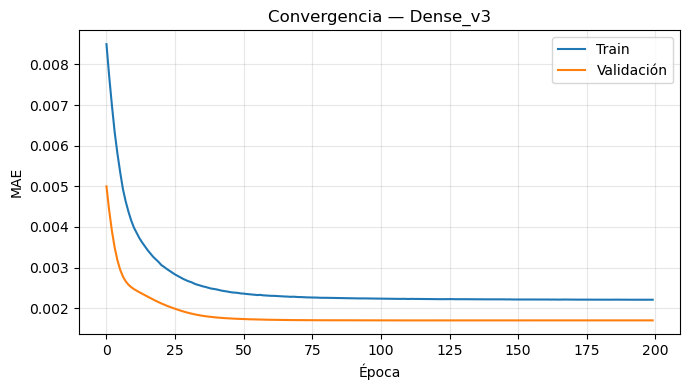

In [54]:
graficar_convergencia(hist_dense_v3, 'Dense_v3')
resultado_dense_v3 = evaluar_modelo(modelo_dense_v3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v3')
print(resultado_dense_v3)

### Dense v4 -- 2 capas con regularizacion L2 (128->64)

In [55]:
modelo_dense_v4 = construir_dense_v4(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v4, lr=1e-3, l2=1e-4)
modelo_dense_v4.summary()
hist_dense_v4 = modelo_dense_v4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=400, batch_size=13765 ,   verbose=1)

Model: "Dense_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 128)            │        88,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,199 (383.59 KB)

 Trainable params: 98,199 (383.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step - loss: 0.0458 - val_loss: 0.0369
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0425 - val_loss: 0.0351
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0400 - val_loss: 0.0337
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0379 - val_loss: 0.0326
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0361 - val_loss: 0.0316
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0345 - val_loss: 0.0306
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0330 - val_loss: 0.0296
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0317 - val_loss: 0.0287
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0304 - val_loss: 0.0278
Epoch 10/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0293 - val_loss: 0.0269
Epoch 11/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0282 - val_loss: 0.0261
Epoch 12/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.027

{'modelo': 'Dense_v4', 'mae_train': 0.0022024974305157393, 'mae_val': 0.001701378817869934, 'mae_test': 0.0023191534899359902, 'n_params': 98199}


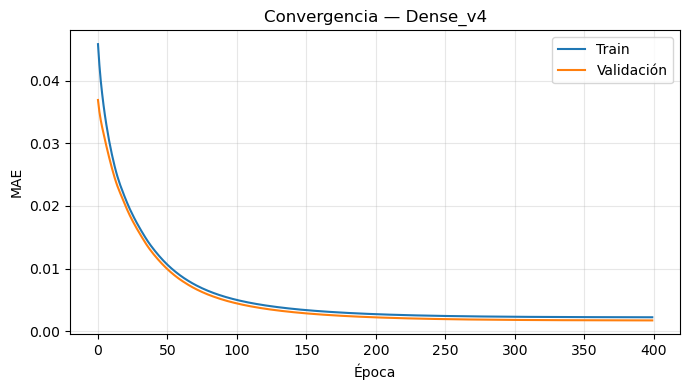

In [56]:
graficar_convergencia(hist_dense_v4, 'Dense_v4')
resultado_dense_v4 = evaluar_modelo(modelo_dense_v4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v4')
print(resultado_dense_v4)

### Dense v5 -- 1 capa oculta grande (256) con activacion tanh

In [57]:
modelo_dense_v5 = construir_dense_v5(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v5, lr=1e-3, l2=1e-4)
modelo_dense_v5.summary()
hist_dense_v5 = modelo_dense_v5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=13765 ,   verbose=1)

Model: "Dense_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,807 (714.09 KB)

 Trainable params: 182,807 (714.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step - loss: 0.0239 - val_loss: 0.0153
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0224 - val_loss: 0.0138
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0208 - val_loss: 0.0128
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0195 - val_loss: 0.0120
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0185 - val_loss: 0.0113
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0177 - val_loss: 0.0107
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0170 - val_loss: 0.0102
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0163 - val_loss: 0.0097
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0158 - val_loss: 0.0092
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0151 - val_loss: 0.0086
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0144 - val_loss: 0.0081
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0138 

{'modelo': 'Dense_v5', 'mae_train': 0.0021213258029041267, 'mae_val': 0.001703354138248479, 'mae_test': 0.002382474232837621, 'n_params': 182807}


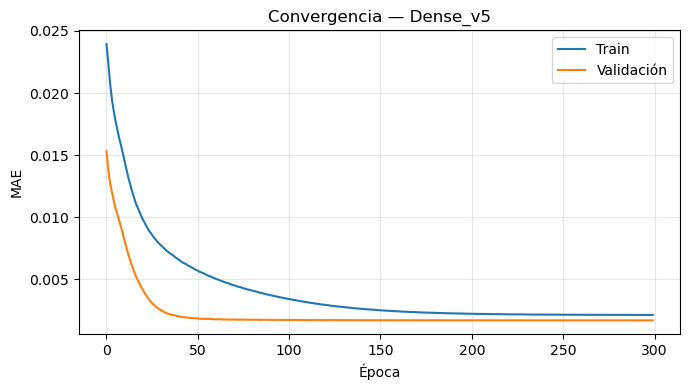

In [58]:
graficar_convergencia(hist_dense_v5, 'Dense_v5')
resultado_dense_v5 = evaluar_modelo(modelo_dense_v5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v5')
print(resultado_dense_v5)

### Dense v6 -- arquitectura piramidal inversa (32->64->128), activacion elu

In [59]:
modelo_dense_v6 = construir_dense_v6(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v6, lr=5e-4, l2=1e-5)
modelo_dense_v6.summary()
hist_dense_v6 = modelo_dense_v6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=13765 ,   verbose=1)

Model: "Dense_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │        22,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,511 (138.71 KB)

 Trainable params: 35,511 (138.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0185 - val_loss: 0.0112
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0178 - val_loss: 0.0105
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0170 - val_loss: 0.0100
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0164 - val_loss: 0.0095
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0158 - val_loss: 0.0091
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0151 - val_loss: 0.0087
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0146 - val_loss: 0.0083
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0140 - val_loss: 0.0079
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0135 - val_loss: 0.0076
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0129 - val_loss: 0.0072
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0125 - val_loss: 0.0069
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0120 - va

{'modelo': 'Dense_v6', 'mae_train': 0.0021936776342201146, 'mae_val': 0.0016959522811336007, 'mae_test': 0.002320224716621107, 'n_params': 35511}


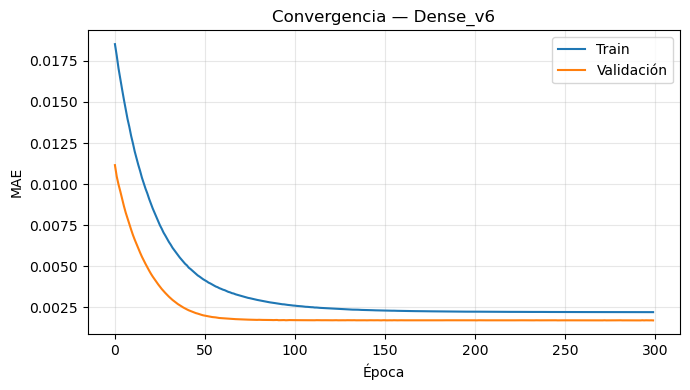

In [60]:
graficar_convergencia(hist_dense_v6, 'Dense_v6')
resultado_dense_v6 = evaluar_modelo(modelo_dense_v6, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v6')
print(resultado_dense_v6)

In [61]:
modelos_dense = [
    ("Dense",    modelo_dense,    X_train_plano, y_train, X_val_plano, y_val, X_test_plano, y_test),
    ("Dense_v2", modelo_dense_v2, X_train_plano, y_train, X_val_plano, y_val, X_test_plano, y_test),
    ("Dense_v3", modelo_dense_v3, X_train_plano, y_train, X_val_plano, y_val, X_test_plano, y_test),
    ("Dense_v4", modelo_dense_v4, X_train_plano, y_train, X_val_plano, y_val, X_test_plano, y_test),
    ("Dense_v5", modelo_dense_v5, X_train_plano, y_train, X_val_plano, y_val, X_test_plano, y_test),
    ("Dense_v6", modelo_dense_v6, X_train_plano, y_train, X_val_plano, y_val, X_test_plano, y_test),
]

print(f"{"Modelo":<12} {"MAE Train":>10} {"MAE Val":>10} {"MAE Test":>10}")
print("=" * 45)
for r in [resultado_lineal, resultado_bah]:
    print(f"{r['modelo']:<12} {r['mae_train']:>10.6f} {r['mae_val']:>10.6f} {r['mae_test']:>10.6f}")
print("-" * 45)
for nombre, modelo, Xtr, ytr, Xv, yv, Xts, yts in modelos_dense:
    r = evaluar_modelo(modelo, Xtr, ytr, Xv, yv, Xts, yts, nombre=nombre)
    print(f"{r['modelo']:<12} {r['mae_train']:>10.6f} {r['mae_val']:>10.6f} {r['mae_test']:>10.6f}")


Modelo        MAE Train    MAE Val   MAE Test
Lineal         0.002148   0.001739   0.002435
BuyAndHold     0.002205   0.001702   0.002320
---------------------------------------------
Dense          0.002203   0.001702   0.002351
Dense_v2       0.002210   0.001700   0.002357
Dense_v3       0.002200   0.001701   0.002325
Dense_v4       0.002202   0.001701   0.002319
Dense_v5       0.002121   0.001703   0.002382
Dense_v6       0.002194   0.001696   0.002320


## 1.4 Modelos Recurrentes (LSTM / GRU)

In [62]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0038 - val_loss: 0.0037
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - loss: 0.0045 - val_loss: 0.0028
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - loss: 0.0037 - val_loss: 0.0027
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - loss: 0.0036 - val_loss: 0.0028
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - loss: 0.0038 - val_loss: 0.0027
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - loss: 0.0035 - val_loss: 0.0024
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - loss: 0.0032

{'modelo': 'LSTM', 'mae_train': 0.002191965313490234, 'mae_val': 0.0017145542282726283, 'mae_test': 0.0023550185834833193, 'n_params': 24023}


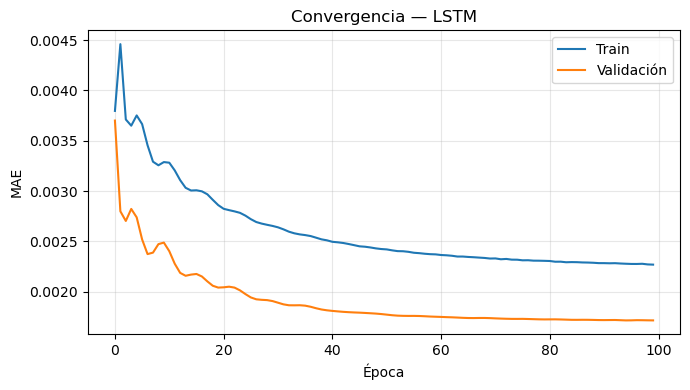

In [63]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)

### Recurrente v2 -- 2 capas LSTM apiladas (64->32)

In [64]:
modelo_lstm_v2 = construir_recurrente_v2(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v2.summary()
hist_lstm_v2 = modelo_lstm_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "LSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0027 - val_loss: 0.0041
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step - loss: 0.0045 - val_loss: 0.0024
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - loss: 0.0032 - val_loss: 0.0023
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step - loss: 0.0030 - val_loss: 0.0022
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step - loss: 0.0026

{'modelo': 'LSTM_v2', 'mae_train': 0.0021834554477960307, 'mae_val': 0.0017033917336308762, 'mae_test': 0.002336117353935836, 'n_params': 35703}


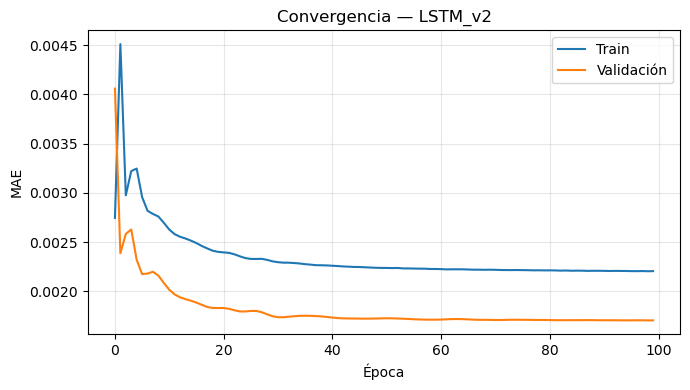

In [65]:
graficar_convergencia(hist_lstm_v2, 'LSTM_v2')
resultado_lstm_v2 = evaluar_modelo(modelo_lstm_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v2')
print(resultado_lstm_v2)

### Recurrente v3 -- GRU bidireccional

In [66]:
modelo_bigru = construir_recurrente_v3(X_train.shape[1:], y_train.shape[1])
modelo_bigru.summary()
hist_bigru = modelo_bigru.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiGRU_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │        10,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,439 (48.59 KB)

 Trainable params: 12,439 (48.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0067 - val_loss: 0.0053
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.0072 - val_loss: 0.0046
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - loss: 0.0066 - val_loss: 0.0045
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - loss: 0.0065 - val_loss: 0.0045
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 0.0064 - val_loss: 0.0044
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - loss: 0.0063 - val_loss: 0.0042
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - loss: 0.0061 - val_loss: 0.0040
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 0.0060 - val_loss: 0.0040
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - loss: 0.0059 - val_loss: 0.0039
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 0.0057 - val_loss: 0.0038
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.0056

{'modelo': 'BiGRU_v3', 'mae_train': 0.00233896312913241, 'mae_val': 0.0018103136904278193, 'mae_test': 0.00249204203151347, 'n_params': 12439}


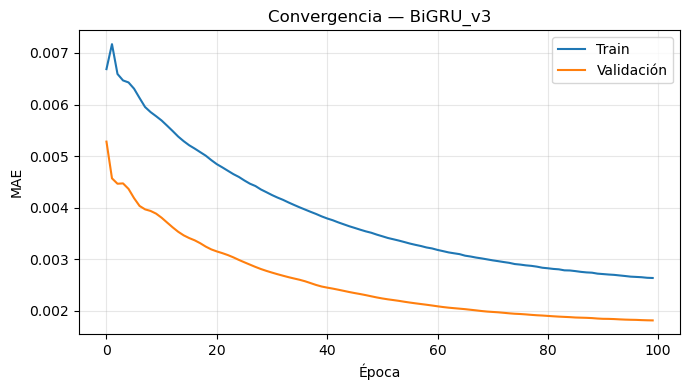

In [67]:
graficar_convergencia(hist_bigru, 'BiGRU_v3')
resultado_bigru = evaluar_modelo(modelo_bigru, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='BiGRU_v3')
print(resultado_bigru)

### Recurrente v4 -- LSTM + Dense intermedia (64 LSTM -> 32 Dense -> salida)

In [68]:
modelo_lstm_v4 = construir_recurrente_v4(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v4.summary()
hist_lstm_v4 = modelo_lstm_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "LSTM_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,367 (99.09 KB)

 Trainable params: 25,367 (99.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0030 - val_loss: 0.0021
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 0.0023 - val_loss: 0.0017
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - loss: 0.0022

{'modelo': 'LSTM_v4', 'mae_train': 0.0022024492413915612, 'mae_val': 0.001701553564654742, 'mae_test': 0.0023189803372814584, 'n_params': 25367}


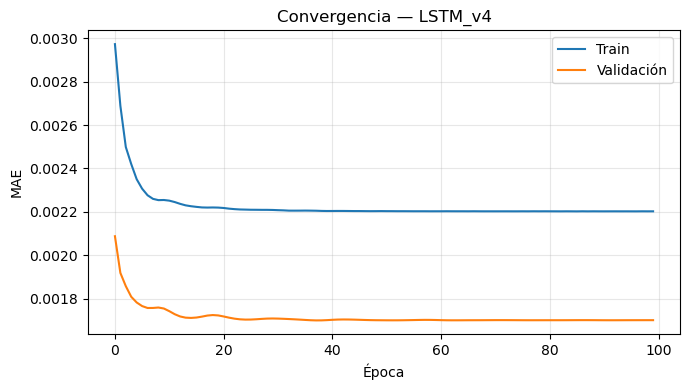

In [69]:
graficar_convergencia(hist_lstm_v4, 'LSTM_v4')
resultado_lstm_v4 = evaluar_modelo(modelo_lstm_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v4')
print(resultado_lstm_v4)

### Recurrente v5 -- LSTM 128 unidades con recurrent_dropout, LR=1e-4

In [70]:
modelo_lstm_v5 = construir_recurrente_v5(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v5.summary()
hist_lstm_v5 = modelo_lstm_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "LSTM_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 128)            │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,791 (315.59 KB)

 Trainable params: 80,791 (315.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0032 - val_loss: 0.0023
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step - loss: 0.0030 - val_loss: 0.0022
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step - loss: 0.0030 - val_loss: 0.0022
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step - loss: 0.0030 - val_loss: 0.0022
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - loss: 0.0030

{'modelo': 'LSTM_v5', 'mae_train': 0.0023928662147656896, 'mae_val': 0.0018529810487233416, 'mae_test': 0.0025444947836912725, 'n_params': 80791}


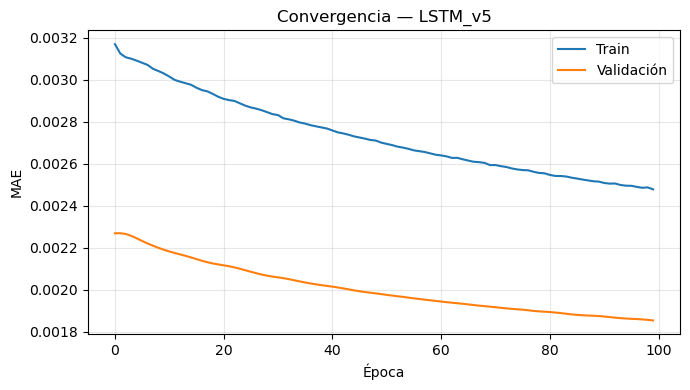

In [71]:
graficar_convergencia(hist_lstm_v5, 'LSTM_v5')
resultado_lstm_v5 = evaluar_modelo(modelo_lstm_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v5')
print(resultado_lstm_v5)

### Recurrente v6 -- 2 capas GRU apiladas (64->32)

In [72]:
modelo_gru_v6 = construir_recurrente_v6(X_train.shape[1:], y_train.shape[1])
modelo_gru_v6.summary()
hist_gru_v6 = modelo_gru_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "GRU_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 30, 64)         │        17,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,255 (106.46 KB)

 Trainable params: 27,255 (106.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0038 - val_loss: 0.0051
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step - loss: 0.0059 - val_loss: 0.0031
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step - loss: 0.0042 - val_loss: 0.0032
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step - loss: 0.0042 - val_loss: 0.0029
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step - loss: 0.0040 - val_loss: 0.0028
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step - loss: 0.0038 - val_loss: 0.0025
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step - loss: 0.0035 - val_loss: 0.0025
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step - loss: 0.0034 - val_loss: 0.0025
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step - loss: 0.0035 - val_loss: 0.0025
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step - loss: 0.0033

{'modelo': 'GRU_v6', 'mae_train': 0.0021972946392044457, 'mae_val': 0.0017116174689249177, 'mae_test': 0.0023367418540810544, 'n_params': 27255}


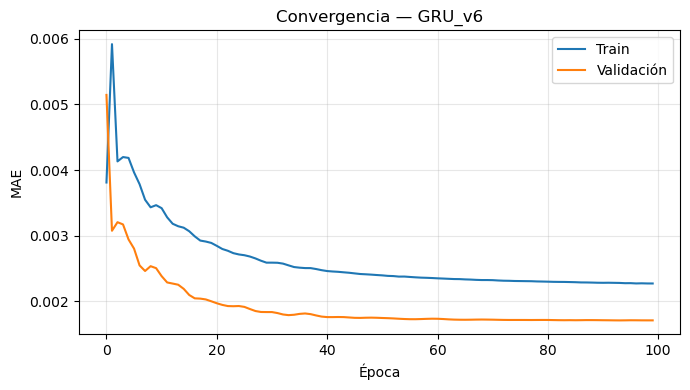

In [73]:
graficar_convergencia(hist_gru_v6, 'GRU_v6')
resultado_gru_v6 = evaluar_modelo(modelo_gru_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='GRU_v6')
print(resultado_gru_v6)

## 1.5 Modelos Conv1D

In [74]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 28, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 28, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0066 - val_loss: 0.0027
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - loss: 0.0024

{'modelo': 'Conv1D', 'mae_train': 0.002193101609770607, 'mae_val': 0.0017052604864644446, 'mae_test': 0.002318759180929175, 'n_params': 11415}


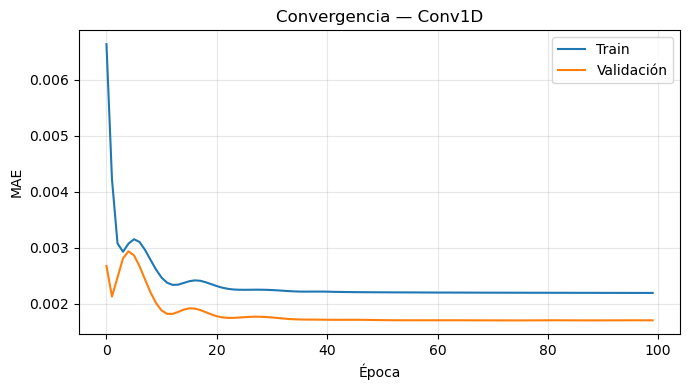

In [75]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)

### Conv1D v2 -- 1 capa Conv1D + Flatten (modelo mas simple)

In [76]:
modelo_conv_v2 = construir_conv1d_v2(X_train.shape[1:], y_train.shape[1])
modelo_conv_v2.summary()
hist_conv_v2 = modelo_conv_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 30, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 23)             │        22,103 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,343 (95.09 KB)

 Trainable params: 24,343 (95.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0131 - val_loss: 0.0076
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0115 - val_loss: 0.0069
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.0106 - val_loss: 0.0065
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 0.0100 - val_loss: 0.0062
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 0.0095 - val_loss: 0.0058
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0090 - val_loss: 0.0053
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0084 - val_loss: 0.0049
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.0078 - val_loss: 0.0045
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0073 - val_loss: 0.0041
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0068 - val_loss: 0.0038
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0063 - val_loss: 0.0035
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0059

{'modelo': 'Conv1D_v2', 'mae_train': 0.002234156510559336, 'mae_val': 0.0017042808085111604, 'mae_test': 0.0024329495013583322, 'n_params': 24343}


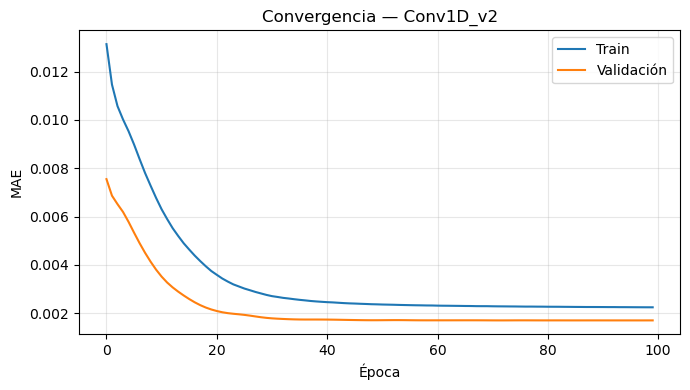

In [77]:
graficar_convergencia(hist_conv_v2, 'Conv1D_v2')
resultado_conv_v2 = evaluar_modelo(modelo_conv_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v2')
print(resultado_conv_v2)

### Conv1D v3 -- 3 capas Conv1D (64->32->16) + GlobalAveragePooling

In [78]:
modelo_conv_v3 = construir_conv1d_v3(X_train.shape[1:], y_train.shape[1])
modelo_conv_v3.summary()
hist_conv_v3 = modelo_conv_v3.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 30, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 23)             │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,599 (49.21 KB)

 Trainable params: 12,599 (49.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0031 - val_loss: 0.0018
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 0.0023

{'modelo': 'Conv1D_v3', 'mae_train': 0.002188205026471598, 'mae_val': 0.0017033126328325975, 'mae_test': 0.0023178686103133813, 'n_params': 12599}


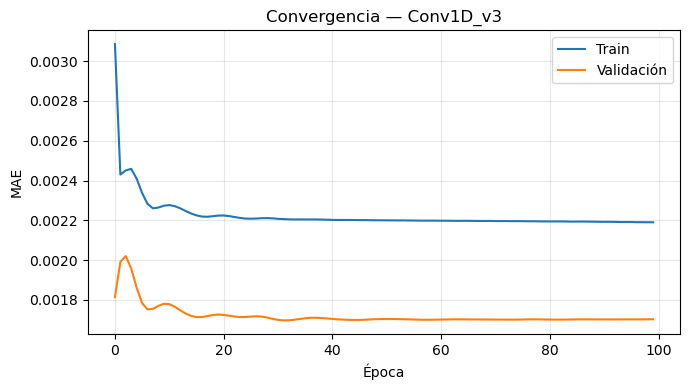

In [79]:
graficar_convergencia(hist_conv_v3, 'Conv1D_v3')
resultado_conv_v3 = evaluar_modelo(modelo_conv_v3, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v3')
print(resultado_conv_v3)

### Conv1D v4 -- Conv1D dilatada (dilation_rate=2), campo receptivo ampliado

In [80]:
modelo_conv_v4 = construir_conv1d_v4(X_train.shape[1:], y_train.shape[1])
modelo_conv_v4.summary()
hist_conv_v4 = modelo_conv_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)              │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0044 - val_loss: 0.0020
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - loss: 0.0031 - val_loss: 0.0021
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 0.0023

{'modelo': 'Conv1D_v4', 'mae_train': 0.0021849969593249526, 'mae_val': 0.0016992497115953687, 'mae_test': 0.002321339483111051, 'n_params': 11415}


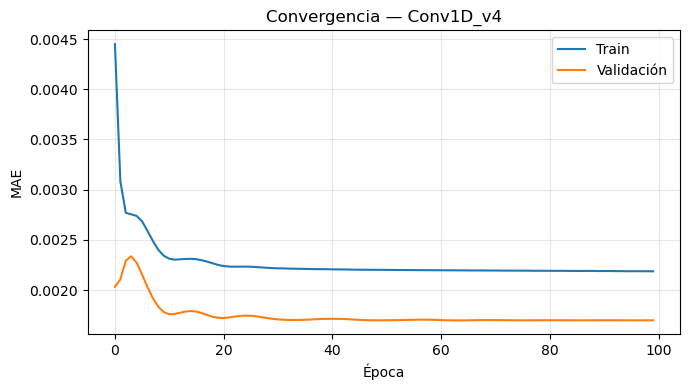

In [81]:
graficar_convergencia(hist_conv_v4, 'Conv1D_v4')
resultado_conv_v4 = evaluar_modelo(modelo_conv_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v4')
print(resultado_conv_v4)

### Conv1D v5 -- SeparableConv1D (menos parametros, mismo campo receptivo)

In [82]:
modelo_conv_v5 = construir_conv1d_v5(X_train.shape[1:], y_train.shape[1])
modelo_conv_v5.summary()
hist_conv_v5 = modelo_conv_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "Conv1D_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 30, 64)         │         1,605 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 30, 32)         │         2,272 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,636 (18.11 KB)

 Trainable params: 4,636 (18.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0023 - val_loss: 0.0020
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - loss: 0.0023 - val_loss: 0.0017
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - loss: 0.0022

{'modelo': 'Conv1D_v5', 'mae_train': 0.0022024939594766256, 'mae_val': 0.0017012954227958023, 'mae_test': 0.002319081313506873, 'n_params': 4636}


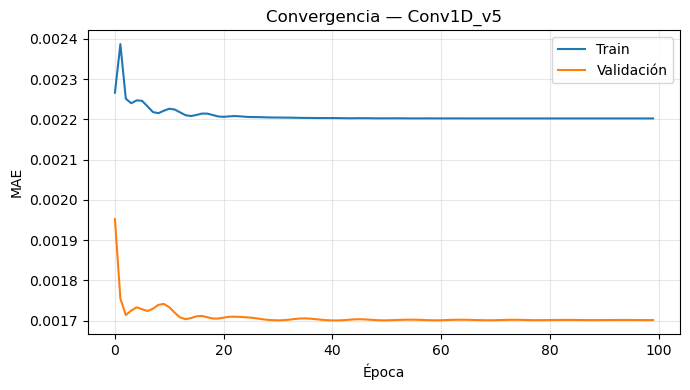

In [83]:
graficar_convergencia(hist_conv_v5, 'Conv1D_v5')
resultado_conv_v5 = evaluar_modelo(modelo_conv_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v5')
print(resultado_conv_v5)

### Conv1D v6 -- Conv1D + MaxPooling1D + Flatten

In [84]:
modelo_conv_v6 = construir_conv1d_v6(X_train.shape[1:], y_train.shape[1])
modelo_conv_v6.summary()
hist_conv_v6 = modelo_conv_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 23)             │        11,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,719 (84.84 KB)

 Trainable params: 21,719 (84.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0139 - val_loss: 0.0058
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - loss: 0.0090 - val_loss: 0.0045
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step - loss: 0.0067 - val_loss: 0.0042
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - loss: 0.0059 - val_loss: 0.0039
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - loss: 0.0045 - val_loss: 0.0030
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step - loss: 0.0039 - val_loss: 0.0026
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - loss: 0.0034 - val_loss: 0.0023
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step - loss: 0.0025

{'modelo': 'Conv1D_v6', 'mae_train': 0.0022026978182535474, 'mae_val': 0.0017015806508097208, 'mae_test': 0.002327172954751816, 'n_params': 21719}


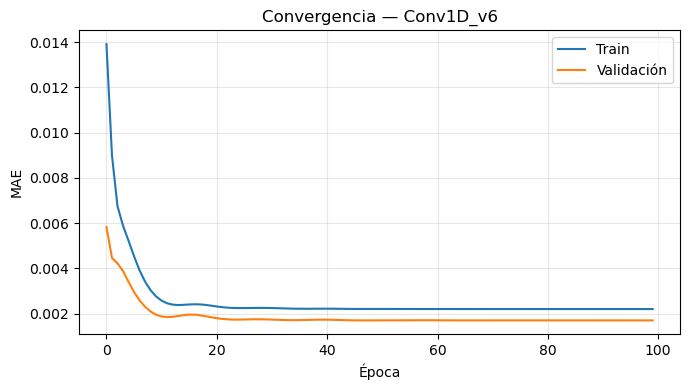

In [85]:
graficar_convergencia(hist_conv_v6, 'Conv1D_v6')
resultado_conv_v6 = evaluar_modelo(modelo_conv_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v6')
print(resultado_conv_v6)

## 1.6 Modelo Mixto (Conv1D + LSTM)

In [86]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Mixto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,999 (152.34 KB)

 Trainable params: 38,999 (152.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - loss: 0.0037 - val_loss: 0.0031
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - loss: 0.0039 - val_loss: 0.0028
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - loss: 0.0034 - val_loss: 0.0026
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step - loss: 0.00

{'modelo': 'Mixto', 'mae_train': 0.0021817451178176113, 'mae_val': 0.0017113690197795859, 'mae_test': 0.002372394443109831, 'n_params': 38999}


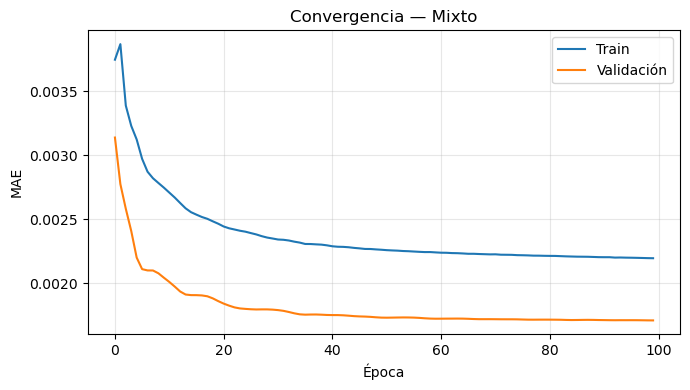

In [87]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

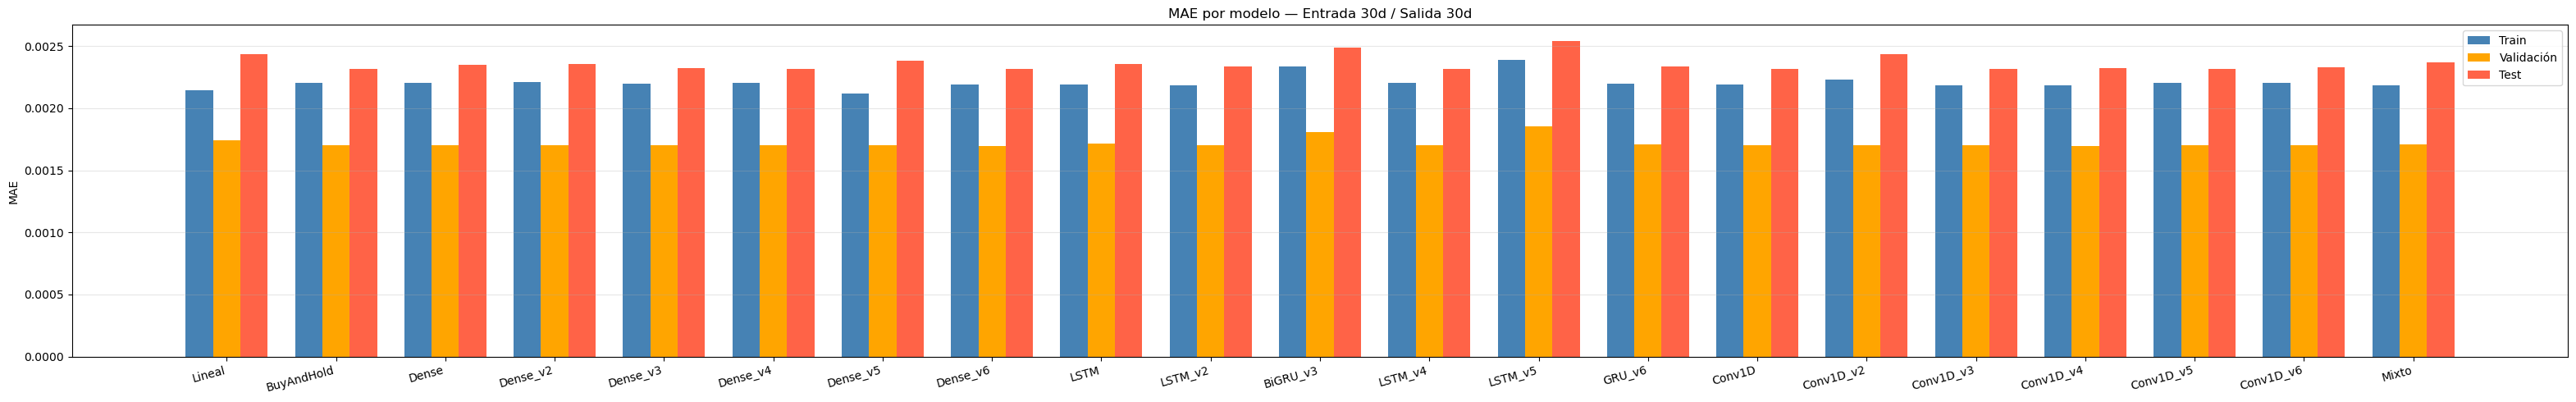

Resultados [competicion] guardados en: ../resultados/metricas/ent30_sal30.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.002148,0.001739,0.002435,0
BuyAndHold,0.002205,0.001702,0.002320,0
Dense,0.002203,0.001702,0.002351,212759
Dense_v2,0.002210,0.001700,0.002357,99543
Dense_v3,0.002200,0.001701,0.002325,527767
Dense_v4,0.002202,0.001701,0.002319,98199
Dense_v5,0.002121,0.001703,0.002382,182807
Dense_v6,0.002194,0.001696,0.002320,35511
LSTM,0.002192,0.001715,0.002355,24023


In [88]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    # Dense
    resultado_dense, resultado_dense_v2, resultado_dense_v3,
    resultado_dense_v4, resultado_dense_v5, resultado_dense_v6,
    # Recurrente
    resultado_lstm, resultado_lstm_v2, resultado_bigru,
    resultado_lstm_v4, resultado_lstm_v5, resultado_gru_v6,
    # Conv1D
    resultado_conv, resultado_conv_v2, resultado_conv_v3,
    resultado_conv_v4, resultado_conv_v5, resultado_conv_v6,
    # Mixto
    resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))

---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [89]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


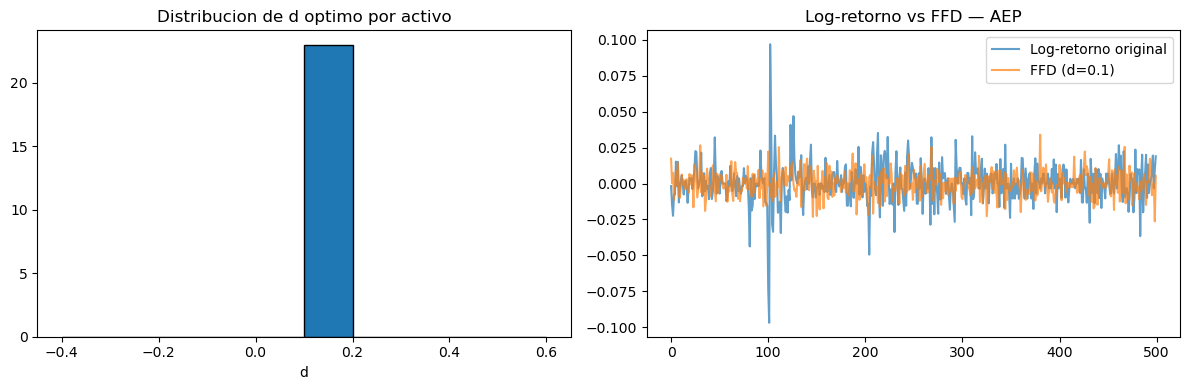

In [90]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [91]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


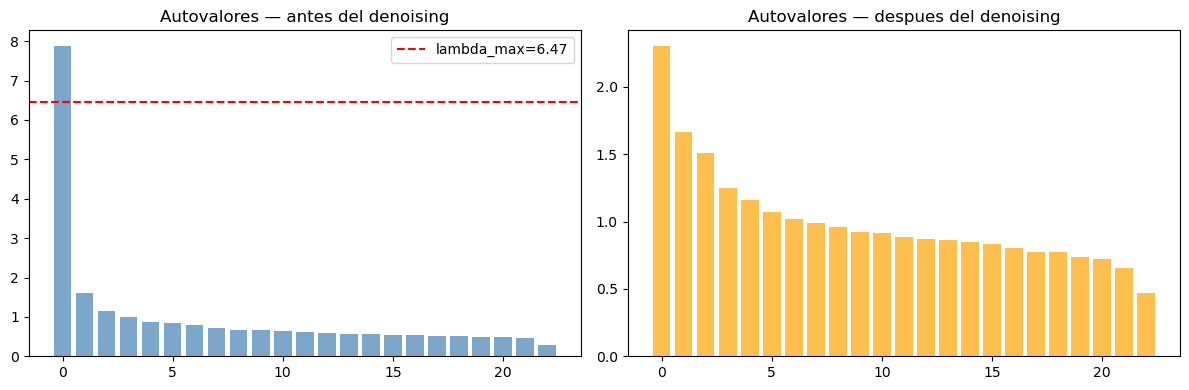

In [92]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [93]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (12661, 30, 23)  Val: (1407, 30, 23)  Test: (1564, 30, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Conv1D
Epoch 1/100


c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2622 - val_loss: 0.1600
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 0.2282 - val_loss: 0.1371
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 0.1995 - val_loss: 0.1194
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.1775 - val_loss: 0.1068
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.1602 - val_loss: 0.0983
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.1477 - val_loss: 0.0928
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 0.1378 - val_loss: 0.0895
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 0.1310 - val_loss: 0.0875
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 0.1255 - val_loss: 0.0864
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.1216 - val_loss: 0.0857
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.1180 - val_loss: 0.0851
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 0.1152 - val_loss:

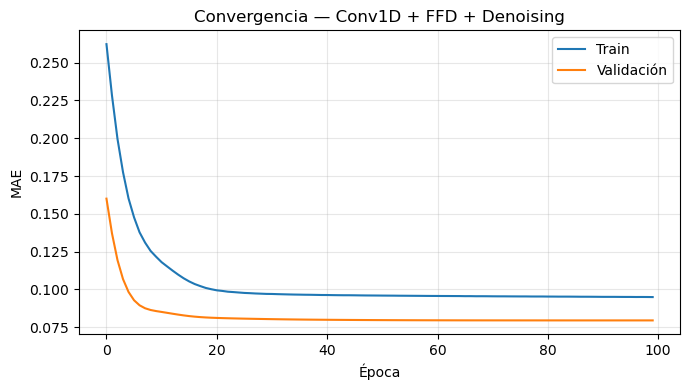

In [94]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=30000,   verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Conv1D,0.002193,0.001705,0.002319,11415
Conv1D_prep,0.094754,0.079506,0.105588,11415


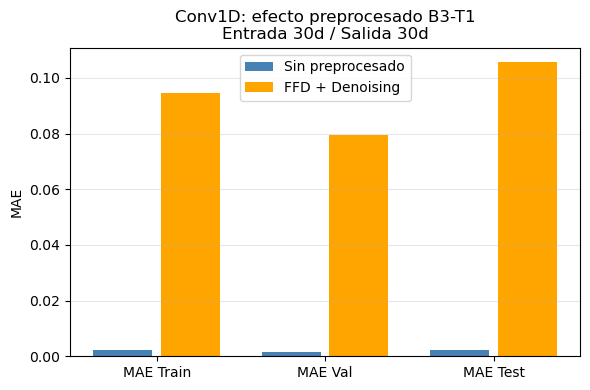

Variacion MAE test con preprocesado: -4453.6%
Resultados [investigacion] guardados en: ../resultados/metricas/ent30_sal30.json


In [95]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
